Dataset: /kaggle/input/datasets/muhammadrizky0909/ml-slot-charger/dataset_slot
Total: 1096 | 0: 548 | 1: 548

===== FOLD 1/5 =====


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


I0000 00:00:1781364340.911601     100 service.cc:152] XLA service 0x7f7c30003710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781364340.911662     100 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781364342.462286     100 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781364351.354209     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


55/55 ━━━━━━━━━━━━━━━━━━━━ 45s 480ms/step - accuracy: 0.4692 - loss: 0.7453 - val_accuracy: 0.5682 - val_loss: 0.6346
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.6199 - loss: 0.6154 - val_accuracy: 0.7773 - val_loss: 0.5128
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.7317 - loss: 0.5288 - val_accuracy: 0.8909 - val_loss: 0.4228
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.8208 - loss: 0.4539 - val_accuracy: 0.9455 - val_loss: 0.3532
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8642 - loss: 0.3982 - val_accuracy: 0.9773 - val_loss: 0.2990
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9155 - loss: 0.3461 - val_accuracy: 0.9818 - val_loss: 0.2569
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9212 - loss: 0.3159 - val_accuracy: 0.9909 - val_loss: 0.2239
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9429 - loss: 0.2843 - val_accuracy: 0.9909 - val_loss: 

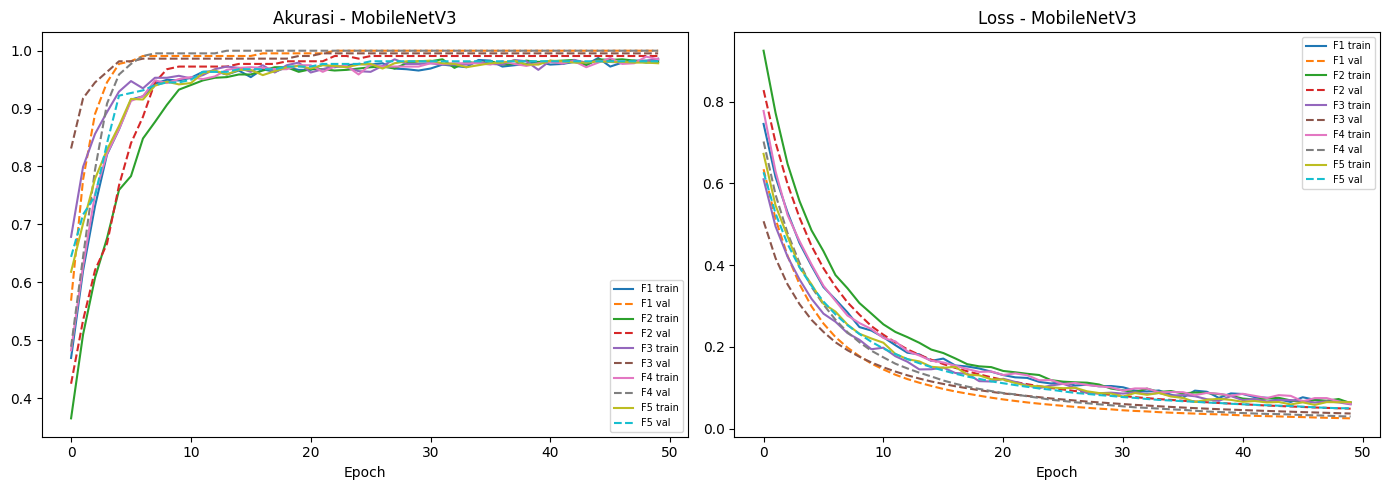

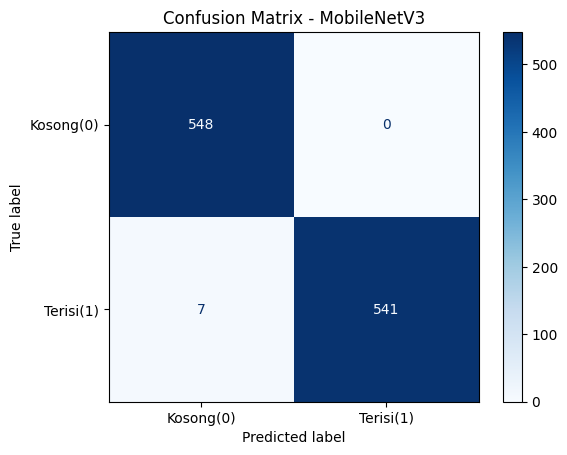

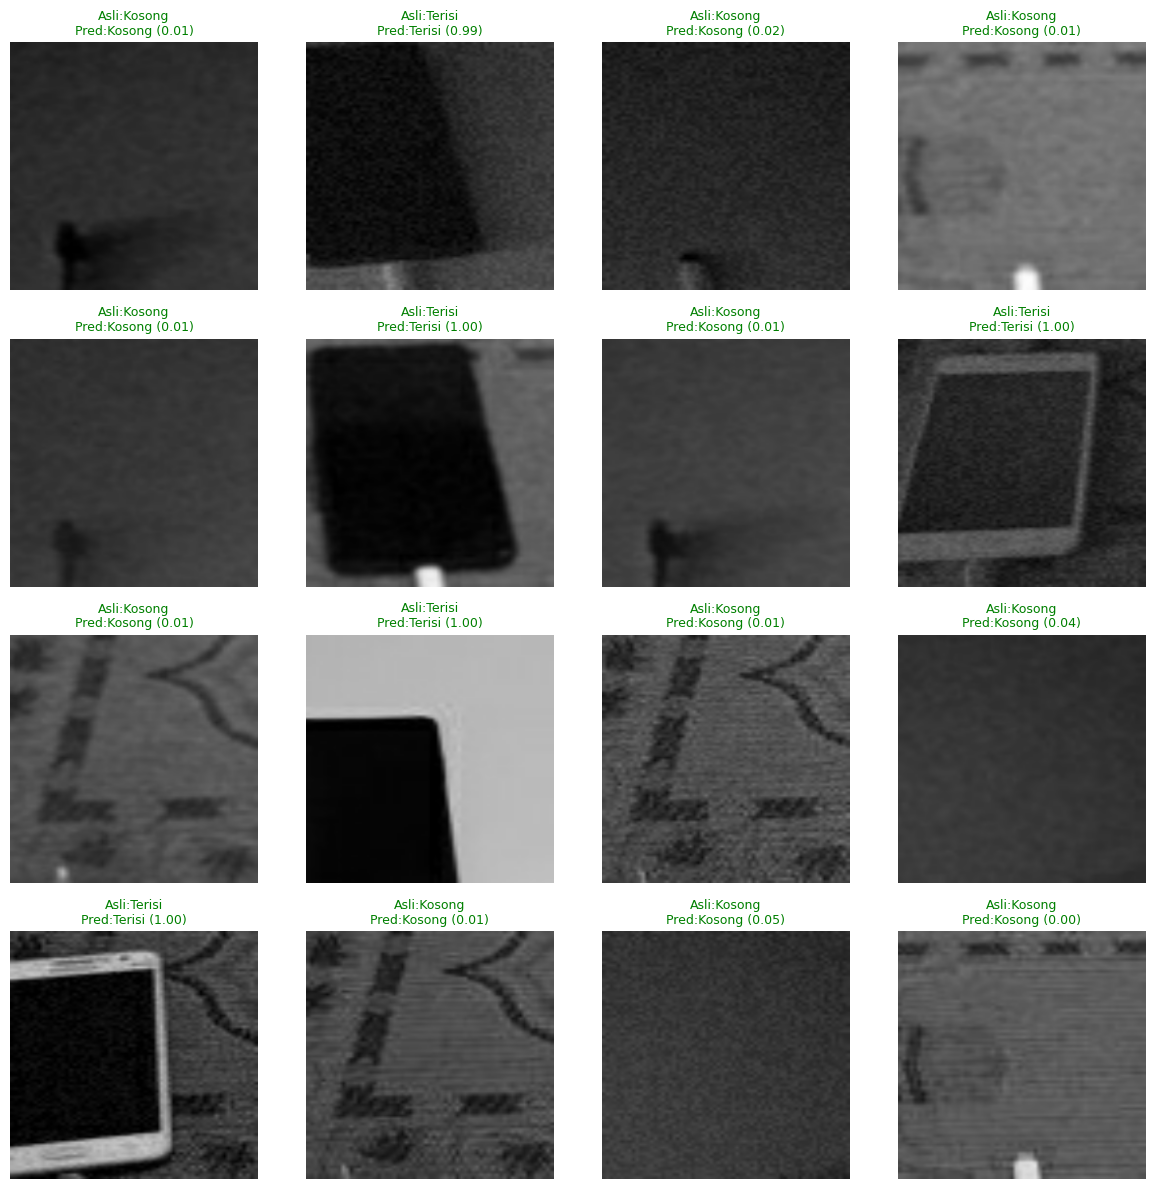

In [1]:
# =========================================================
# MobileNetV3Large — Train + Metrik + Visualisasi + Save Best (Opsi B)
# =========================================================
import os, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error,
                             ConfusionMatrixDisplay)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# ---------- KONFIG ----------
MODEL_NAME = "MobileNetV3"
IMG_SIZE, BATCH_SIZE, LR, DROPOUT, EPOCHS = (256, 256), 16, 1e-4, 0.2, 50
N_SPLITS, SEED, AUTOTUNE = 5, 123, tf.data.AUTOTUNE

# 🔹 BARU (1): siapkan folder simpan + tracker fold terbaik
SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)
best_fold_acc, best_fold = 0.0, None
BEST_PATH = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras")

# ---------- DATA ----------
def find_data_dir(root="/kaggle/input"):
    for dp, dn, _ in os.walk(root):
        if "0" in dn and "1" in dn: return dp
    raise FileNotFoundError("Folder subfolder '0' & '1' tidak ditemukan")
DATA_DIR = find_data_dir(); print("Dataset:", DATA_DIR)

paths, labels = [], []
for lab in ["0", "1"]:
    folder = os.path.join(DATA_DIR, lab)
    for f in os.listdir(folder):
        if f.lower().endswith((".jpg",".jpeg",".png")):
            paths.append(os.path.join(folder, f)); labels.append(int(lab))
paths, labels = np.array(paths), np.array(labels)
print("Total:", len(paths), "| 0:", (labels==0).sum(), "| 1:", (labels==1).sum())

augment = tf.keras.Sequential([
    tf.keras.layers.RandomBrightness(0.2, value_range=(0,255)),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomRotation(0.03),
], name="augmentasi")

def load_image(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32), label

def make_ds(idx, training):
    ds = tf.data.Dataset.from_tensor_slices((paths[idx], labels[idx])).map(load_image, AUTOTUNE)
    if training:
        ds = ds.shuffle(512, seed=SEED).batch(BATCH_SIZE)
        ds = ds.map(lambda x,y:(augment(x,training=True),y), AUTOTUNE)
    else:
        ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

# ---------- MODEL (khas MobileNetV3) ----------
def build_model():
    base = tf.keras.applications.MobileNetV3Large(
        input_shape=IMG_SIZE+(3,), include_top=False,
        weights="imagenet", include_preprocessing=True)   # input [0,255]
    base.trainable = False
    inp = tf.keras.Input(shape=IMG_SIZE+(3,))
    x = base(inp, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(DROPOUT)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(LR),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

# ---------- TRAIN 5-FOLD ----------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
acc_per_fold, histories, y_true_all, y_prob_all = [], [], [], []
for fold,(tr,va) in enumerate(skf.split(paths, labels), 1):
    print(f"\n===== FOLD {fold}/{N_SPLITS} =====")
    train_ds, val_ds = make_ds(tr, True), make_ds(va, False)
    model = build_model()
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[es], verbose=1)
    _, acc = model.evaluate(val_ds, verbose=0); print(f"Fold {fold} acc: {acc:.4f}")
    acc_per_fold.append(acc); histories.append(h.history)
    y_prob_all.append(model.predict(val_ds, verbose=0).ravel())
    y_true_all.append(np.concatenate([y.numpy() for _,y in val_ds]))

    # 🔹 BARU (2): simpan HANYA jika fold ini lebih baik dari sebelumnya
    if acc > best_fold_acc:
        best_fold_acc, best_fold = acc, fold
        model.save(BEST_PATH)
        print(f"✅ Model terbaik diperbarui -> fold {fold} (acc {acc:.4f}) disimpan ke {BEST_PATH}")

y_true_all = np.concatenate(y_true_all)
y_prob_all = np.concatenate(y_prob_all)
y_pred_all = (y_prob_all>=0.5).astype(int)

# 🔹 BARU (3): ringkasan model terbaik yang tersimpan
print(f"\n🏆 Fold terbaik: {best_fold} | Akurasi: {best_fold_acc:.4f}")
print(f"📁 File model final: {BEST_PATH}")

# ---------- METRIK ----------
acc  = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all)
rec  = recall_score(y_true_all, y_pred_all)
f1   = f1_score(y_true_all, y_pred_all)
rmse = np.sqrt(mean_squared_error(y_true_all, y_prob_all))
mae  = mean_absolute_error(y_true_all, y_prob_all)
print(f"\n=== {MODEL_NAME} === Acc {acc:.4f} | Prec {prec:.4f} | Rec {rec:.4f} | F1 {f1:.4f}")
print(f"RMSE {rmse:.4f} | MAE {mae:.4f} (dari probabilitas)")
print(f"Rata-rata akurasi 5-fold: {np.mean(acc_per_fold):.4f} (+/- {np.std(acc_per_fold):.4f})")
print(classification_report(y_true_all, y_pred_all, target_names=["Kosong(0)","Terisi(1)"]))

try: all_results
except NameError: all_results = {}
all_results[MODEL_NAME] = {"Accuracy":acc,"Precision":prec,"Recall":rec,"F1":f1,"RMSE":rmse,"MAE":mae}

print("\n=== Akurasi Training vs Test per Fold ===")
tr_list, te_list = [], []
for i, hh in enumerate(histories, 1):
    best = int(np.argmin(hh["val_loss"]))   # epoch dgn val_loss terbaik (= bobot yg dipakai)
    tr, te = hh["accuracy"][best], hh["val_accuracy"][best]
    tr_list.append(tr); te_list.append(te)
    print(f"Fold {i}: Train {tr:.4f} | Test {te:.4f}")
print(f"Rata-rata: Train {np.mean(tr_list):.4f} | Test {np.mean(te_list):.4f}")

# ---------- VISUALISASI ----------
fig, ax = plt.subplots(1, 2, figsize=(14,5))
for i,hh in enumerate(histories,1):
    ax[0].plot(hh["accuracy"], label=f"F{i} train"); ax[0].plot(hh["val_accuracy"], "--", label=f"F{i} val")
    ax[1].plot(hh["loss"],     label=f"F{i} train"); ax[1].plot(hh["val_loss"], "--", label=f"F{i} val")
ax[0].set_title(f"Akurasi - {MODEL_NAME}"); ax[1].set_title(f"Loss - {MODEL_NAME}")
ax[0].set_xlabel("Epoch"); ax[1].set_xlabel("Epoch")
ax[0].legend(fontsize=7); ax[1].legend(fontsize=7); plt.tight_layout(); plt.show()

ConfusionMatrixDisplay.from_predictions(y_true_all, y_pred_all,
    display_labels=["Kosong(0)","Terisi(1)"], cmap="Blues")
plt.title(f"Confusion Matrix - {MODEL_NAME}"); plt.show()

rng = np.random.default_rng(SEED); sidx = rng.choice(len(paths), 16, replace=False)
imgs = tf.stack([load_image(p,0)[0] for p in paths[sidx]])
probs = model.predict(imgs, verbose=0).ravel(); preds=(probs>=0.5).astype(int)
nm={0:"Kosong",1:"Terisi"}; plt.figure(figsize=(12,12))
for i in range(16):
    plt.subplot(4,4,i+1); plt.imshow(imgs[i].numpy().astype("uint8"))
    a,p = labels[sidx[i]], preds[i]
    plt.title(f"Asli:{nm[a]}\nPred:{nm[p]} ({probs[i]:.2f})", color="green" if a==p else "red", fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

Dataset: /kaggle/input/datasets/muhammadrizky0909/ml-slot-charger/dataset_slot
Total: 1096 | 0: 548 | 1: 548

===== FOLD 1/5 =====
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
53/55 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6509 - loss: 0.6432

2026-06-13 15:44:58.211560: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 15:44:58.447372: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 15:44:59.281947: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 15:44:59.541133: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 211ms/step - accuracy: 0.6553 - loss: 0.6464 - val_accuracy: 0.8000 - val_loss: 0.4148
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.7123 - loss: 0.5280 - val_accuracy: 0.8273 - val_loss: 0.3685
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.7546 - loss: 0.4900 - val_accuracy: 0.8545 - val_loss: 0.3345
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.7648 - loss: 0.4690 - val_accuracy: 0.8773 - val_loss: 0.3048
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.8025 - loss: 0.4208 - val_accuracy: 0.9000 - val_loss: 0.2770
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.8048 - loss: 0.4153 - val_accuracy: 0.9000 - val_loss: 0.2546
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.8345 - loss: 0.3692 - val_accuracy: 0.9182 - val_loss: 0.2366
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.8299 - loss: 0.3752 - val_accuracy: 0.9182 - val_loss: 

2026-06-13 15:48:58.744298: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 15:48:58.980662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 15:48:59.785321: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 15:49:00.045045: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.4093 - loss: 1.1249

2026-06-13 15:49:05.817333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 15:49:06.053463: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 15:49:06.798582: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 15:49:07.057714: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


55/55 ━━━━━━━━━━━━━━━━━━━━ 19s 295ms/step - accuracy: 0.4960 - loss: 0.9519 - val_accuracy: 0.5068 - val_loss: 0.7644
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.5587 - loss: 0.8421 - val_accuracy: 0.5708 - val_loss: 0.6633
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.5884 - loss: 0.7265 - val_accuracy: 0.6438 - val_loss: 0.5841
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.6488 - loss: 0.6486 - val_accuracy: 0.6941 - val_loss: 0.5244
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.6454 - loss: 0.6096 - val_accuracy: 0.7306 - val_loss: 0.4738
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.7115 - loss: 0.5218 - val_accuracy: 0.7626 - val_loss: 0.4298
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.7377 - loss: 0.4865 - val_accuracy: 0.7945 - val_loss: 0.3950
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.7731 - loss: 0.4442 - val_accuracy: 0.8493 - val_loss: 

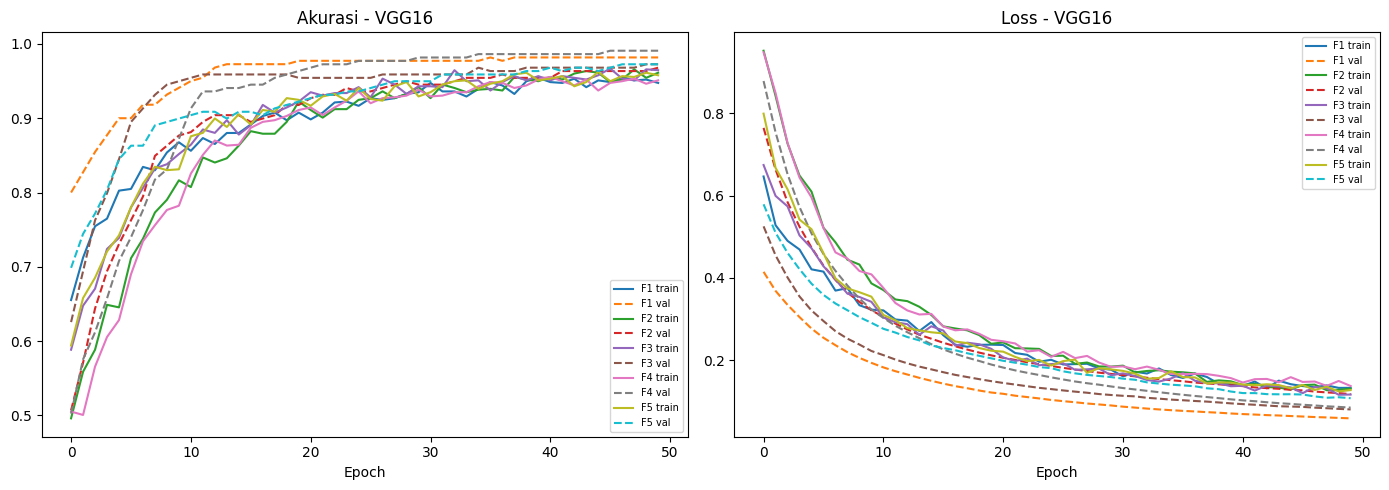

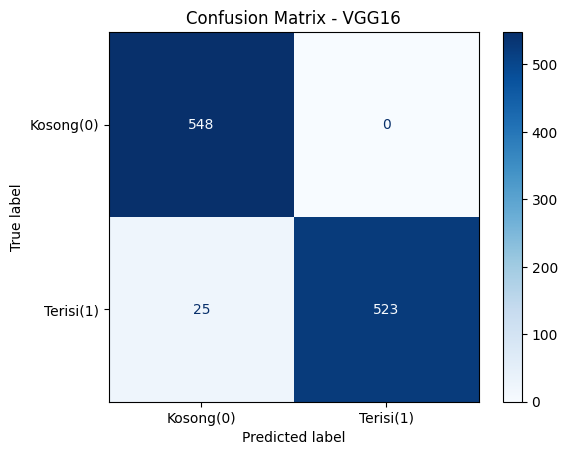

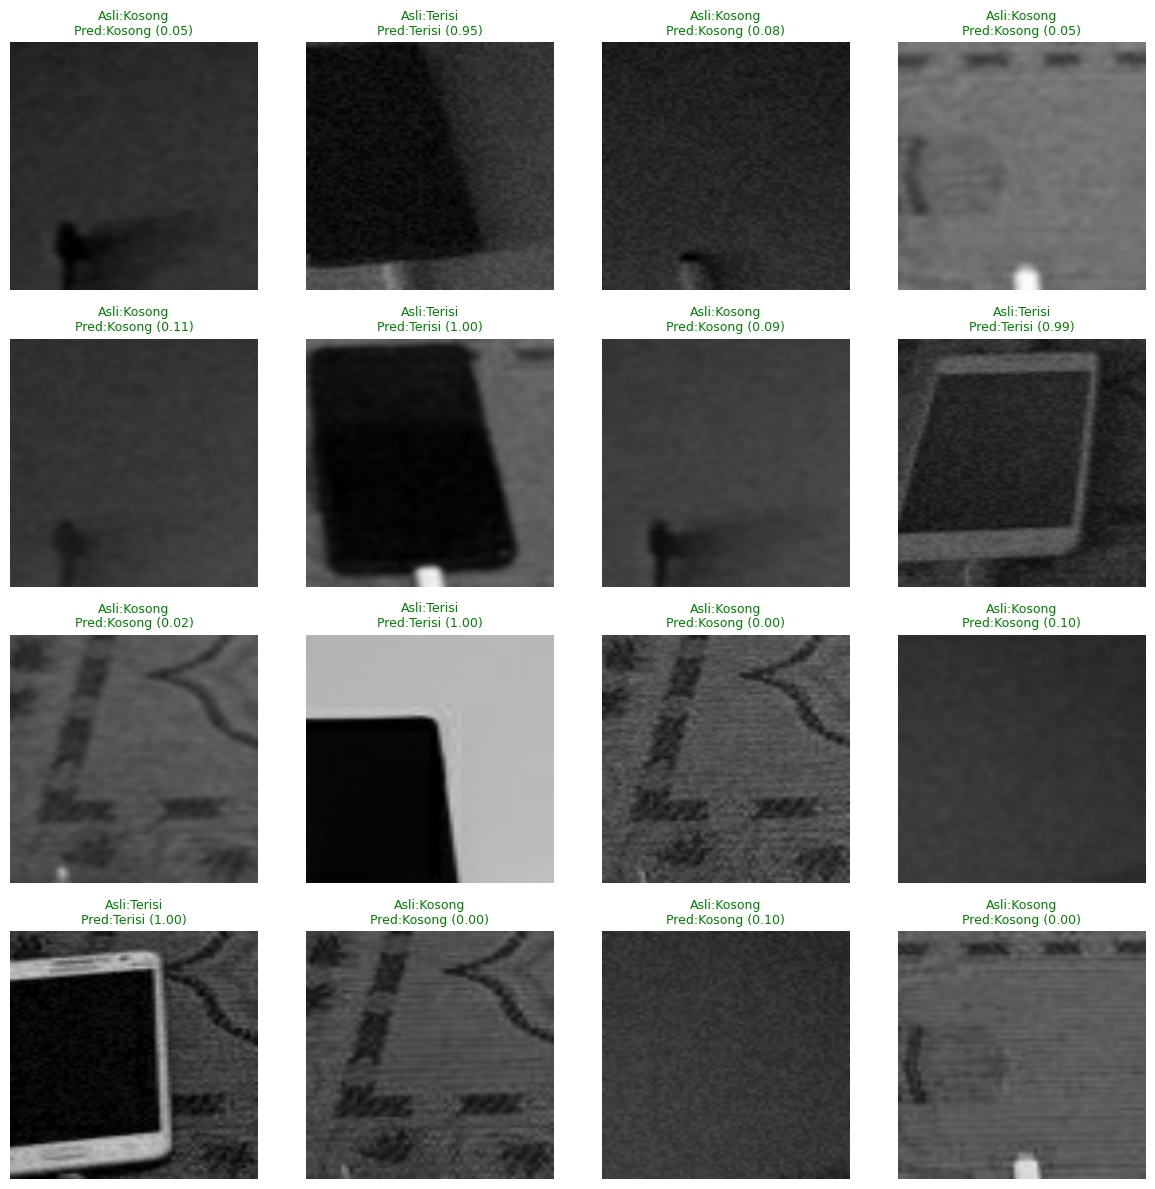

In [2]:
# =========================================================
# VGG16 — Train + Metrik + Visualisasi + Save Best (Opsi B)
# =========================================================
import os, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error,
                             ConfusionMatrixDisplay)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# ---------- KONFIG ----------
MODEL_NAME = "VGG16"
IMG_SIZE, BATCH_SIZE, LR, DROPOUT, EPOCHS = (256, 256), 16, 1e-4, 0.2, 50
N_SPLITS, SEED, AUTOTUNE = 5, 123, tf.data.AUTOTUNE

# 🔹 BARU (1): siapkan folder simpan + tracker fold terbaik
SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)
best_fold_acc, best_fold = 0.0, None
BEST_PATH = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras")

# ---------- DATA ----------
def find_data_dir(root="/kaggle/input"):
    for dp, dn, _ in os.walk(root):
        if "0" in dn and "1" in dn: return dp
    raise FileNotFoundError("Folder subfolder '0' & '1' tidak ditemukan")
DATA_DIR = find_data_dir(); print("Dataset:", DATA_DIR)

paths, labels = [], []
for lab in ["0", "1"]:
    folder = os.path.join(DATA_DIR, lab)
    for f in os.listdir(folder):
        if f.lower().endswith((".jpg",".jpeg",".png")):
            paths.append(os.path.join(folder, f)); labels.append(int(lab))
paths, labels = np.array(paths), np.array(labels)
print("Total:", len(paths), "| 0:", (labels==0).sum(), "| 1:", (labels==1).sum())

augment = tf.keras.Sequential([
    tf.keras.layers.RandomBrightness(0.2, value_range=(0,255)),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomRotation(0.03),
], name="augmentasi")

def load_image(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32), label

def make_ds(idx, training):
    ds = tf.data.Dataset.from_tensor_slices((paths[idx], labels[idx])).map(load_image, AUTOTUNE)
    if training:
        ds = ds.shuffle(512, seed=SEED).batch(BATCH_SIZE)
        ds = ds.map(lambda x,y:(augment(x,training=True),y), AUTOTUNE)
    else:
        ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

# ---------- MODEL (khas VGG16) ----------
def build_model():
    base = tf.keras.applications.VGG16(
        input_shape=IMG_SIZE+(3,), include_top=False, weights="imagenet")
    base.trainable = False
    inp = tf.keras.Input(shape=IMG_SIZE+(3,))
    x = tf.keras.layers.Lambda(tf.keras.applications.vgg16.preprocess_input)(inp)  # khas VGG16
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(DROPOUT)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(LR),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

# ---------- TRAIN 5-FOLD ----------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
acc_per_fold, histories, y_true_all, y_prob_all = [], [], [], []
for fold,(tr,va) in enumerate(skf.split(paths, labels), 1):
    print(f"\n===== FOLD {fold}/{N_SPLITS} =====")
    train_ds, val_ds = make_ds(tr, True), make_ds(va, False)
    model = build_model()
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[es], verbose=1)
    _, acc = model.evaluate(val_ds, verbose=0); print(f"Fold {fold} acc: {acc:.4f}")
    acc_per_fold.append(acc); histories.append(h.history)
    y_prob_all.append(model.predict(val_ds, verbose=0).ravel())
    y_true_all.append(np.concatenate([y.numpy() for _,y in val_ds]))

    # 🔹 BARU (2): simpan HANYA jika fold ini lebih baik dari sebelumnya
    if acc > best_fold_acc:
        best_fold_acc, best_fold = acc, fold
        model.save(BEST_PATH)
        print(f"✅ Model terbaik diperbarui -> fold {fold} (acc {acc:.4f}) disimpan ke {BEST_PATH}")

y_true_all = np.concatenate(y_true_all)
y_prob_all = np.concatenate(y_prob_all)
y_pred_all = (y_prob_all>=0.5).astype(int)

# 🔹 BARU (3): ringkasan model terbaik yang tersimpan
print(f"\n🏆 Fold terbaik: {best_fold} | Akurasi: {best_fold_acc:.4f}")
print(f"📁 File model final: {BEST_PATH}")

# ---------- METRIK ----------
acc  = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all)
rec  = recall_score(y_true_all, y_pred_all)
f1   = f1_score(y_true_all, y_pred_all)
rmse = np.sqrt(mean_squared_error(y_true_all, y_prob_all))
mae  = mean_absolute_error(y_true_all, y_prob_all)
print(f"\n=== {MODEL_NAME} === Acc {acc:.4f} | Prec {prec:.4f} | Rec {rec:.4f} | F1 {f1:.4f}")
print(f"RMSE {rmse:.4f} | MAE {mae:.4f} (dari probabilitas)")
print(f"Rata-rata akurasi 5-fold: {np.mean(acc_per_fold):.4f} (+/- {np.std(acc_per_fold):.4f})")
print(classification_report(y_true_all, y_pred_all, target_names=["Kosong(0)","Terisi(1)"]))

try: all_results
except NameError: all_results = {}
all_results[MODEL_NAME] = {"Accuracy":acc,"Precision":prec,"Recall":rec,"F1":f1,"RMSE":rmse,"MAE":mae}

print("\n=== Akurasi Training vs Test per Fold ===")
tr_list, te_list = [], []
for i, hh in enumerate(histories, 1):
    best = int(np.argmin(hh["val_loss"]))   # epoch dgn val_loss terbaik (= bobot yg dipakai)
    tr, te = hh["accuracy"][best], hh["val_accuracy"][best]
    tr_list.append(tr); te_list.append(te)
    print(f"Fold {i}: Train {tr:.4f} | Test {te:.4f}")
print(f"Rata-rata: Train {np.mean(tr_list):.4f} | Test {np.mean(te_list):.4f}")

# ---------- VISUALISASI ----------
fig, ax = plt.subplots(1, 2, figsize=(14,5))
for i,hh in enumerate(histories,1):
    ax[0].plot(hh["accuracy"], label=f"F{i} train"); ax[0].plot(hh["val_accuracy"], "--", label=f"F{i} val")
    ax[1].plot(hh["loss"],     label=f"F{i} train"); ax[1].plot(hh["val_loss"], "--", label=f"F{i} val")
ax[0].set_title(f"Akurasi - {MODEL_NAME}"); ax[1].set_title(f"Loss - {MODEL_NAME}")
ax[0].set_xlabel("Epoch"); ax[1].set_xlabel("Epoch")
ax[0].legend(fontsize=7); ax[1].legend(fontsize=7); plt.tight_layout(); plt.show()

ConfusionMatrixDisplay.from_predictions(y_true_all, y_pred_all,
    display_labels=["Kosong(0)","Terisi(1)"], cmap="Blues")
plt.title(f"Confusion Matrix - {MODEL_NAME}"); plt.show()

rng = np.random.default_rng(SEED); sidx = rng.choice(len(paths), 16, replace=False)
imgs = tf.stack([load_image(p,0)[0] for p in paths[sidx]])
probs = model.predict(imgs, verbose=0).ravel(); preds=(probs>=0.5).astype(int)
nm={0:"Kosong",1:"Terisi"}; plt.figure(figsize=(12,12))
for i in range(16):
    plt.subplot(4,4,i+1); plt.imshow(imgs[i].numpy().astype("uint8"))
    a,p = labels[sidx[i]], preds[i]
    plt.title(f"Asli:{nm[a]}\nPred:{nm[p]} ({probs[i]:.2f})", color="green" if a==p else "red", fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

Dataset: /kaggle/input/datasets/muhammadrizky0909/ml-slot-charger/dataset_slot
Total: 1096 | 0: 548 | 1: 548

===== FOLD 1/5 =====
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 28s 277ms/step - accuracy: 0.6872 - loss: 0.5677 - val_accuracy: 0.8909 - val_loss: 0.3975
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.8527 - loss: 0.3889 - val_accuracy: 0.9818 - val_loss: 0.2661
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9155 - loss: 0.2930 - val_accuracy: 0.9864 - val_loss: 0.1979
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.9269 - loss: 0.2385 - val_accuracy: 0.9864 - val_loss: 0.1575
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9338 - loss: 0.2121 - val_accuracy: 0.9864 - val_loss: 0.1301
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9521 - loss: 0.1784 - val_accuracy: 0.9909 - val_loss: 0.1126
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - a

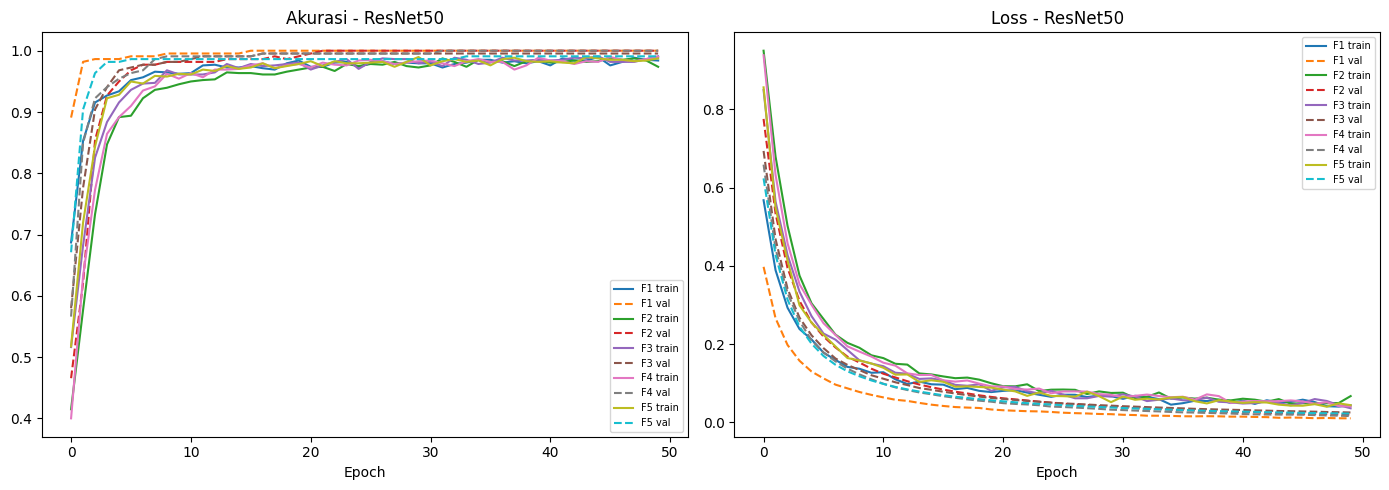

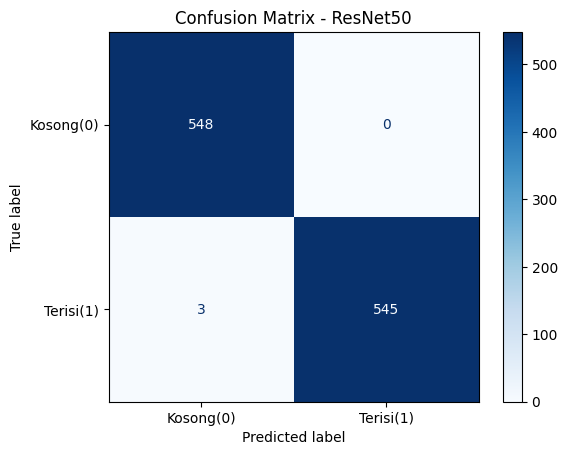

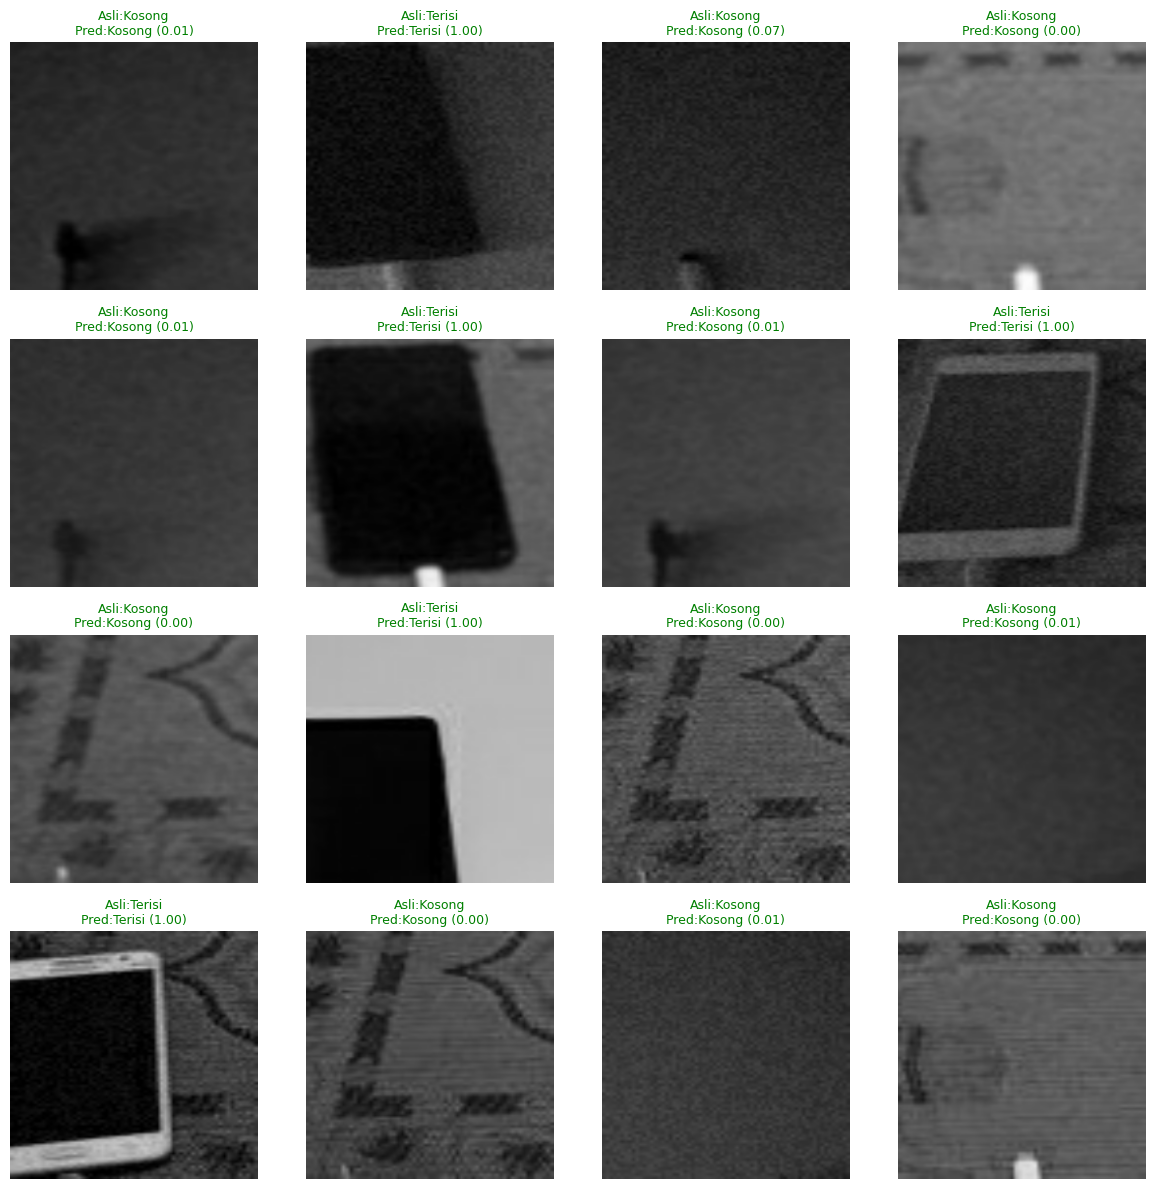

In [3]:
# =========================================================
# ResNet50 — Train + Metrik + Visualisasi + Save Best (Opsi B)
# =========================================================
import os, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error,
                             ConfusionMatrixDisplay)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# ---------- KONFIG ----------
MODEL_NAME = "ResNet50"
IMG_SIZE, BATCH_SIZE, LR, DROPOUT, EPOCHS = (256, 256), 16, 1e-4, 0.2, 50
N_SPLITS, SEED, AUTOTUNE = 5, 123, tf.data.AUTOTUNE

# 🔹 BARU (1): siapkan folder simpan + tracker fold terbaik
SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)
best_fold_acc, best_fold = 0.0, None
BEST_PATH = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras")

# ---------- DATA ----------
def find_data_dir(root="/kaggle/input"):
    for dp, dn, _ in os.walk(root):
        if "0" in dn and "1" in dn: return dp
    raise FileNotFoundError("Folder subfolder '0' & '1' tidak ditemukan")
DATA_DIR = find_data_dir(); print("Dataset:", DATA_DIR)

paths, labels = [], []
for lab in ["0", "1"]:
    folder = os.path.join(DATA_DIR, lab)
    for f in os.listdir(folder):
        if f.lower().endswith((".jpg",".jpeg",".png")):
            paths.append(os.path.join(folder, f)); labels.append(int(lab))
paths, labels = np.array(paths), np.array(labels)
print("Total:", len(paths), "| 0:", (labels==0).sum(), "| 1:", (labels==1).sum())

augment = tf.keras.Sequential([
    tf.keras.layers.RandomBrightness(0.2, value_range=(0,255)),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomRotation(0.03),
], name="augmentasi")

def load_image(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32), label

def make_ds(idx, training):
    ds = tf.data.Dataset.from_tensor_slices((paths[idx], labels[idx])).map(load_image, AUTOTUNE)
    if training:
        ds = ds.shuffle(512, seed=SEED).batch(BATCH_SIZE)
        ds = ds.map(lambda x,y:(augment(x,training=True),y), AUTOTUNE)
    else:
        ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

# ---------- MODEL (khas ResNet50) ----------
def build_model():
    base = tf.keras.applications.ResNet50(
        input_shape=IMG_SIZE+(3,), include_top=False, weights="imagenet")
    base.trainable = False
    inp = tf.keras.Input(shape=IMG_SIZE+(3,))
    x = tf.keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input)(inp)  # khas ResNet50
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(DROPOUT)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(LR),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

# ---------- TRAIN 5-FOLD ----------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
acc_per_fold, histories, y_true_all, y_prob_all = [], [], [], []
for fold,(tr,va) in enumerate(skf.split(paths, labels), 1):
    print(f"\n===== FOLD {fold}/{N_SPLITS} =====")
    train_ds, val_ds = make_ds(tr, True), make_ds(va, False)
    model = build_model()
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[es], verbose=1)
    _, acc = model.evaluate(val_ds, verbose=0); print(f"Fold {fold} acc: {acc:.4f}")
    acc_per_fold.append(acc); histories.append(h.history)
    y_prob_all.append(model.predict(val_ds, verbose=0).ravel())
    y_true_all.append(np.concatenate([y.numpy() for _,y in val_ds]))

    # 🔹 BARU (2): simpan HANYA jika fold ini lebih baik dari sebelumnya
    if acc > best_fold_acc:
        best_fold_acc, best_fold = acc, fold
        model.save(BEST_PATH)
        print(f"✅ Model terbaik diperbarui -> fold {fold} (acc {acc:.4f}) disimpan ke {BEST_PATH}")

y_true_all = np.concatenate(y_true_all)
y_prob_all = np.concatenate(y_prob_all)
y_pred_all = (y_prob_all>=0.5).astype(int)

# 🔹 BARU (3): ringkasan model terbaik yang tersimpan
print(f"\n🏆 Fold terbaik: {best_fold} | Akurasi: {best_fold_acc:.4f}")
print(f"📁 File model final: {BEST_PATH}")

# ---------- METRIK ----------
acc  = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all)
rec  = recall_score(y_true_all, y_pred_all)
f1   = f1_score(y_true_all, y_pred_all)
rmse = np.sqrt(mean_squared_error(y_true_all, y_prob_all))
mae  = mean_absolute_error(y_true_all, y_prob_all)
print(f"\n=== {MODEL_NAME} === Acc {acc:.4f} | Prec {prec:.4f} | Rec {rec:.4f} | F1 {f1:.4f}")
print(f"RMSE {rmse:.4f} | MAE {mae:.4f} (dari probabilitas)")
print(f"Rata-rata akurasi 5-fold: {np.mean(acc_per_fold):.4f} (+/- {np.std(acc_per_fold):.4f})")
print(classification_report(y_true_all, y_pred_all, target_names=["Kosong(0)","Terisi(1)"]))

try: all_results
except NameError: all_results = {}
all_results[MODEL_NAME] = {"Accuracy":acc,"Precision":prec,"Recall":rec,"F1":f1,"RMSE":rmse,"MAE":mae}

print("\n=== Akurasi Training vs Test per Fold ===")
tr_list, te_list = [], []
for i, hh in enumerate(histories, 1):
    best = int(np.argmin(hh["val_loss"]))   # epoch dgn val_loss terbaik (= bobot yg dipakai)
    tr, te = hh["accuracy"][best], hh["val_accuracy"][best]
    tr_list.append(tr); te_list.append(te)
    print(f"Fold {i}: Train {tr:.4f} | Test {te:.4f}")
print(f"Rata-rata: Train {np.mean(tr_list):.4f} | Test {np.mean(te_list):.4f}")

# ---------- VISUALISASI ----------
fig, ax = plt.subplots(1, 2, figsize=(14,5))
for i,hh in enumerate(histories,1):
    ax[0].plot(hh["accuracy"], label=f"F{i} train"); ax[0].plot(hh["val_accuracy"], "--", label=f"F{i} val")
    ax[1].plot(hh["loss"],     label=f"F{i} train"); ax[1].plot(hh["val_loss"], "--", label=f"F{i} val")
ax[0].set_title(f"Akurasi - {MODEL_NAME}"); ax[1].set_title(f"Loss - {MODEL_NAME}")
ax[0].set_xlabel("Epoch"); ax[1].set_xlabel("Epoch")
ax[0].legend(fontsize=7); ax[1].legend(fontsize=7); plt.tight_layout(); plt.show()

ConfusionMatrixDisplay.from_predictions(y_true_all, y_pred_all,
    display_labels=["Kosong(0)","Terisi(1)"], cmap="Blues")
plt.title(f"Confusion Matrix - {MODEL_NAME}"); plt.show()

rng = np.random.default_rng(SEED); sidx = rng.choice(len(paths), 16, replace=False)
imgs = tf.stack([load_image(p,0)[0] for p in paths[sidx]])
probs = model.predict(imgs, verbose=0).ravel(); preds=(probs>=0.5).astype(int)
nm={0:"Kosong",1:"Terisi"}; plt.figure(figsize=(12,12))
for i in range(16):
    plt.subplot(4,4,i+1); plt.imshow(imgs[i].numpy().astype("uint8"))
    a,p = labels[sidx[i]], preds[i]
    plt.title(f"Asli:{nm[a]}\nPred:{nm[p]} ({probs[i]:.2f})", color="green" if a==p else "red", fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

Dataset: /kaggle/input/datasets/muhammadrizky0909/ml-slot-charger/dataset_slot
Total: 1096 | 0: 548 | 1: 548

===== FOLD 1/5 =====
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 289ms/step - accuracy: 0.5776 - loss: 0.6929 - val_accuracy: 0.7818 - val_loss: 0.6134
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.6495 - loss: 0.6402 - val_accuracy: 0.8591 - val_loss: 0.5630
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.7169 - loss: 0.5889 - val_accuracy: 0.9000 - val_loss: 0.5193
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.7546 - loss: 0.5625 - val_accuracy: 0.9455 - val_loss: 0.4787
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.7740 - loss: 0.5493 - val_accuracy: 0.9545 - val_loss: 0.4425
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.8219 - loss: 0.4910 - val_accuracy: 0.9682 - val_loss: 0.4117
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step -

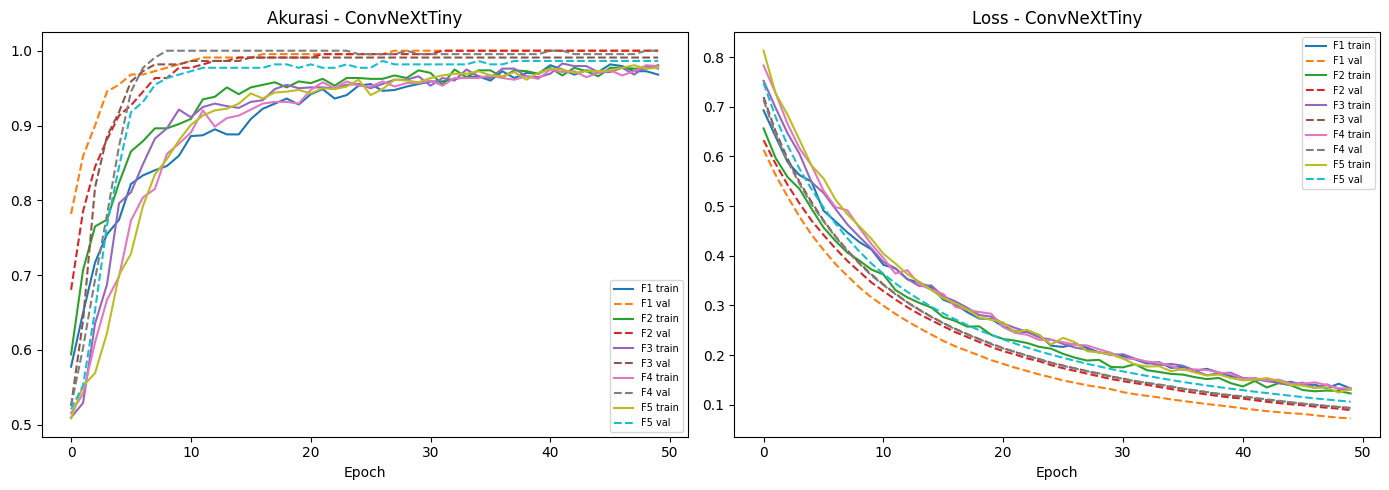

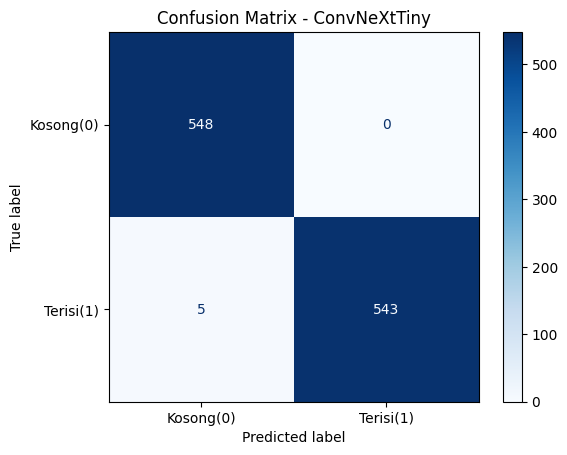

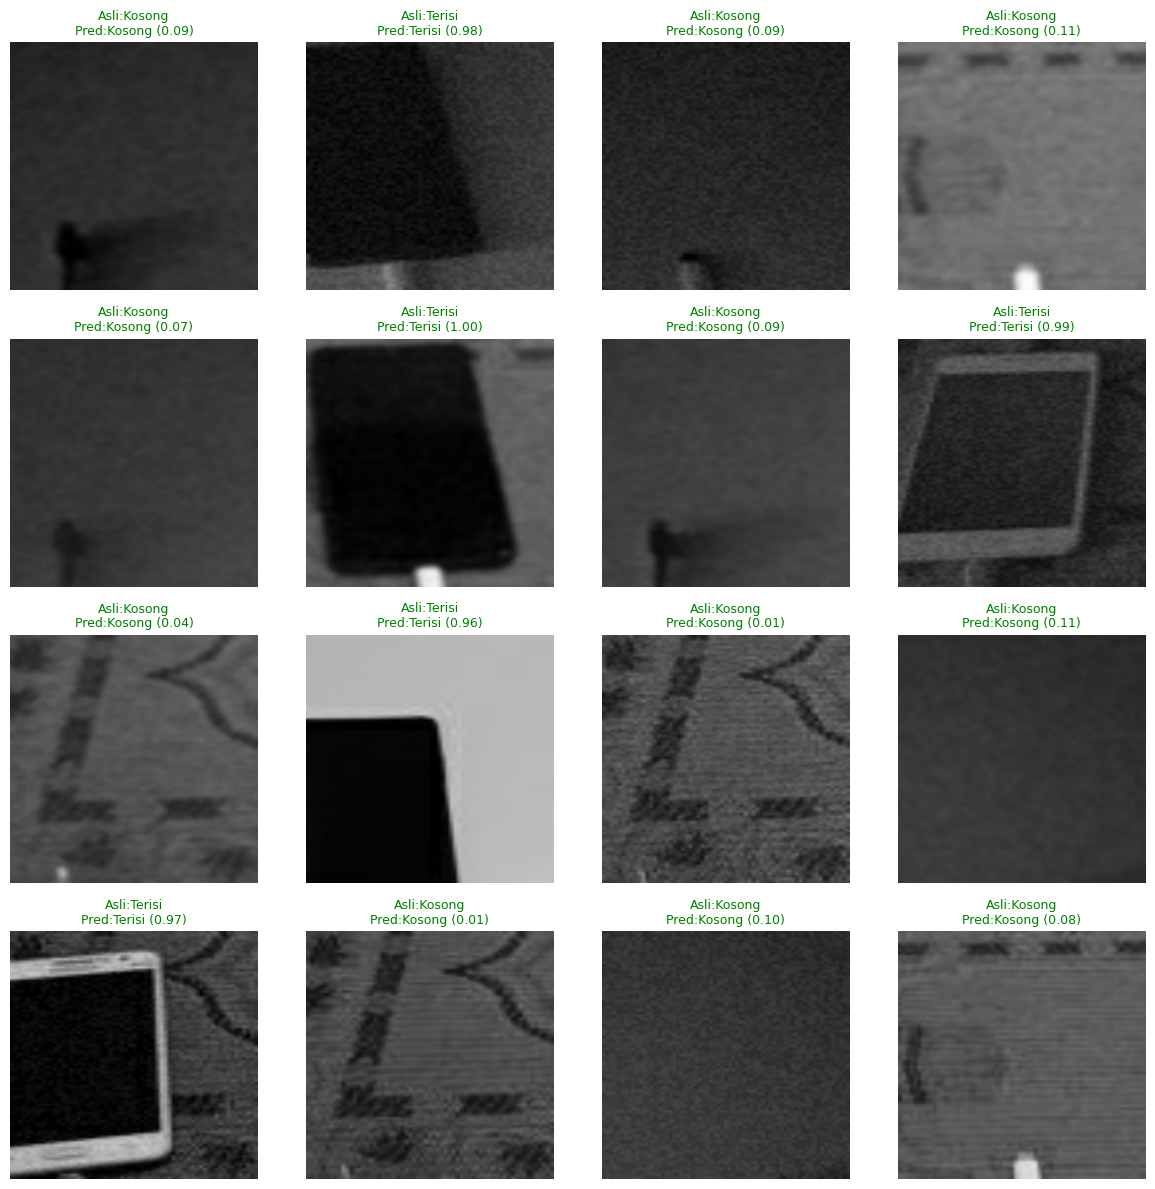

In [4]:
# =========================================================
# ConvNeXt-Tiny — Train + Metrik + Visualisasi + Save Best (Opsi B)
# =========================================================
import os, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error,
                             ConfusionMatrixDisplay)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# ---------- KONFIG ----------
MODEL_NAME = "ConvNeXtTiny"
IMG_SIZE, BATCH_SIZE, LR, DROPOUT, EPOCHS = (256, 256), 16, 1e-4, 0.2, 50
N_SPLITS, SEED, AUTOTUNE = 5, 123, tf.data.AUTOTUNE

# 🔹 BARU (1): siapkan folder simpan + tracker fold terbaik
SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)
best_fold_acc, best_fold = 0.0, None
BEST_PATH = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.keras")

# ---------- DATA ----------
def find_data_dir(root="/kaggle/input"):
    for dp, dn, _ in os.walk(root):
        if "0" in dn and "1" in dn: return dp
    raise FileNotFoundError("Folder subfolder '0' & '1' tidak ditemukan")
DATA_DIR = find_data_dir(); print("Dataset:", DATA_DIR)

paths, labels = [], []
for lab in ["0", "1"]:
    folder = os.path.join(DATA_DIR, lab)
    for f in os.listdir(folder):
        if f.lower().endswith((".jpg",".jpeg",".png")):
            paths.append(os.path.join(folder, f)); labels.append(int(lab))
paths, labels = np.array(paths), np.array(labels)
print("Total:", len(paths), "| 0:", (labels==0).sum(), "| 1:", (labels==1).sum())

augment = tf.keras.Sequential([
    tf.keras.layers.RandomBrightness(0.2, value_range=(0,255)),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomRotation(0.03),
], name="augmentasi")

def load_image(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32), label

def make_ds(idx, training):
    ds = tf.data.Dataset.from_tensor_slices((paths[idx], labels[idx])).map(load_image, AUTOTUNE)
    if training:
        ds = ds.shuffle(512, seed=SEED).batch(BATCH_SIZE)
        ds = ds.map(lambda x,y:(augment(x,training=True),y), AUTOTUNE)
    else:
        ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

# ---------- MODEL (khas ConvNeXt-Tiny) ----------
def build_model():
    base = tf.keras.applications.ConvNeXtTiny(
        input_shape=IMG_SIZE+(3,), include_top=False, weights="imagenet")
    base.trainable = False
    inp = tf.keras.Input(shape=IMG_SIZE+(3,))
    # ConvNeXt punya normalisasi BUILT-IN -> input mentah [0,255], TANPA Lambda preprocess
    x = base(inp, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(DROPOUT)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(LR),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

# ---------- TRAIN 5-FOLD ----------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
acc_per_fold, histories, y_true_all, y_prob_all = [], [], [], []
for fold,(tr,va) in enumerate(skf.split(paths, labels), 1):
    print(f"\n===== FOLD {fold}/{N_SPLITS} =====")
    train_ds, val_ds = make_ds(tr, True), make_ds(va, False)
    model = build_model()
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[es], verbose=1)
    _, acc = model.evaluate(val_ds, verbose=0); print(f"Fold {fold} acc: {acc:.4f}")
    acc_per_fold.append(acc); histories.append(h.history)
    y_prob_all.append(model.predict(val_ds, verbose=0).ravel())
    y_true_all.append(np.concatenate([y.numpy() for _,y in val_ds]))

    # 🔹 BARU (2): simpan HANYA jika fold ini lebih baik dari sebelumnya
    if acc > best_fold_acc:
        best_fold_acc, best_fold = acc, fold
        model.save(BEST_PATH)
        print(f"✅ Model terbaik diperbarui -> fold {fold} (acc {acc:.4f}) disimpan ke {BEST_PATH}")

y_true_all = np.concatenate(y_true_all)
y_prob_all = np.concatenate(y_prob_all)
y_pred_all = (y_prob_all>=0.5).astype(int)

# 🔹 BARU (3): ringkasan model terbaik yang tersimpan
print(f"\n🏆 Fold terbaik: {best_fold} | Akurasi: {best_fold_acc:.4f}")
print(f"📁 File model final: {BEST_PATH}")

# ---------- METRIK ----------
acc  = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all)
rec  = recall_score(y_true_all, y_pred_all)
f1   = f1_score(y_true_all, y_pred_all)
rmse = np.sqrt(mean_squared_error(y_true_all, y_prob_all))
mae  = mean_absolute_error(y_true_all, y_prob_all)
print(f"\n=== {MODEL_NAME} === Acc {acc:.4f} | Prec {prec:.4f} | Rec {rec:.4f} | F1 {f1:.4f}")
print(f"RMSE {rmse:.4f} | MAE {mae:.4f} (dari probabilitas)")
print(f"Rata-rata akurasi 5-fold: {np.mean(acc_per_fold):.4f} (+/- {np.std(acc_per_fold):.4f})")
print(classification_report(y_true_all, y_pred_all, target_names=["Kosong(0)","Terisi(1)"]))

try: all_results
except NameError: all_results = {}
all_results[MODEL_NAME] = {"Accuracy":acc,"Precision":prec,"Recall":rec,"F1":f1,"RMSE":rmse,"MAE":mae}

print("\n=== Akurasi Training vs Test per Fold ===")
tr_list, te_list = [], []
for i, hh in enumerate(histories, 1):
    best = int(np.argmin(hh["val_loss"]))   # epoch dgn val_loss terbaik (= bobot yg dipakai)
    tr, te = hh["accuracy"][best], hh["val_accuracy"][best]
    tr_list.append(tr); te_list.append(te)
    print(f"Fold {i}: Train {tr:.4f} | Test {te:.4f}")
print(f"Rata-rata: Train {np.mean(tr_list):.4f} | Test {np.mean(te_list):.4f}")

# ---------- VISUALISASI ----------
fig, ax = plt.subplots(1, 2, figsize=(14,5))
for i,hh in enumerate(histories,1):
    ax[0].plot(hh["accuracy"], label=f"F{i} train"); ax[0].plot(hh["val_accuracy"], "--", label=f"F{i} val")
    ax[1].plot(hh["loss"],     label=f"F{i} train"); ax[1].plot(hh["val_loss"], "--", label=f"F{i} val")
ax[0].set_title(f"Akurasi - {MODEL_NAME}"); ax[1].set_title(f"Loss - {MODEL_NAME}")
ax[0].set_xlabel("Epoch"); ax[1].set_xlabel("Epoch")
ax[0].legend(fontsize=7); ax[1].legend(fontsize=7); plt.tight_layout(); plt.show()

ConfusionMatrixDisplay.from_predictions(y_true_all, y_pred_all,
    display_labels=["Kosong(0)","Terisi(1)"], cmap="Blues")
plt.title(f"Confusion Matrix - {MODEL_NAME}"); plt.show()

rng = np.random.default_rng(SEED); sidx = rng.choice(len(paths), 16, replace=False)
imgs = tf.stack([load_image(p,0)[0] for p in paths[sidx]])
probs = model.predict(imgs, verbose=0).ravel(); preds=(probs>=0.5).astype(int)
nm={0:"Kosong",1:"Terisi"}; plt.figure(figsize=(12,12))
for i in range(16):
    plt.subplot(4,4,i+1); plt.imshow(imgs[i].numpy().astype("uint8"))
    a,p = labels[sidx[i]], preds[i]
    plt.title(f"Asli:{nm[a]}\nPred:{nm[p]} ({probs[i]:.2f})", color="green" if a==p else "red", fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

In [5]:
import shutil
shutil.make_archive("/kaggle/working/models", "zip", "/kaggle/working/models")
print("✅ Zip dibuat: /kaggle/working/models.zip")

✅ Zip dibuat: /kaggle/working/models.zip


In [1]:
import tensorflow as tf, os

SAVE_DIR = "/kaggle/working/models"
model_files = [
    "ConvNeXtTiny_best.keras",
    "MobileNetV3_best.keras",
    "VGG16_best.keras",
    "ResNet50_best.keras",
]

for fname in model_files:
    path = os.path.join(SAVE_DIR, fname)
    m = tf.keras.models.load_model(path, safe_mode=False)   # load model lengkap
    out = path.replace(".keras", ".weights.h5")
    m.save_weights(out)                                     # simpan bobot saja
    print(f"✅ {fname} -> {os.path.basename(out)}")

✅ ConvNeXtTiny_best.keras -> ConvNeXtTiny_best.weights.h5
✅ MobileNetV3_best.keras -> MobileNetV3_best.weights.h5


TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': {'optimizer': {'module': 'keras.optimizers', 'class_name': 'Adam', 'config': {'name': 'adam', 'learning_rate': 9.999999747378752e-05, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}, 'registered_name': None}, 'loss': 'binary_crossentropy', 'loss_weights': None, 'metrics': ['accuracy'], 'weighted_metr

In [2]:
import tensorflow as tf, os
from tensorflow.keras.applications import vgg16, resnet50

SAVE_DIR = "/kaggle/working/models"

# tiap model dipetakan ke preprocess_input dari modul yang BENAR
custom_map = {
    "VGG16_best.keras":    {"preprocess_input": vgg16.preprocess_input},
    "ResNet50_best.keras": {"preprocess_input": resnet50.preprocess_input},
}

for fname, custom in custom_map.items():
    path = os.path.join(SAVE_DIR, fname)
    m = tf.keras.models.load_model(
        path,
        safe_mode=False,
        custom_objects=custom        # 🔑 kunci perbaikannya
    )
    out = path.replace(".keras", ".weights.h5")
    m.save_weights(out)
    print(f"✅ {fname} -> {os.path.basename(out)}")

✅ VGG16_best.keras -> VGG16_best.weights.h5
✅ ResNet50_best.keras -> ResNet50_best.weights.h5
